## Practica Logistic Regression
### Data Science 8CC2
### Universidad Autónoma de Chihuahua
### Facultad de Ingenieria
### Ingenieria en ciencias de la computación
### Docente: Olanda Prieto Ordaz
### Fecha de entrega: Jueves 25 de septiembre del 2025
*Allan Hall Solorio 358909*

# Introducción

En esta práctica, utilizando una base de datos de Kaggle sobre cancer de pulmón, se llevo a cabo un proceso completo de Data Science para abordar la tarea de predicción de cancer de pulmón en personas mediante modelos de Machine Learning de regresión logística.

Los pasos principales que se realizaron fueron:

1.  **Obtención de los datos:** Descarga del dataset directamente desde Kaggle.
2.  **Exploración inicial de los datos:** Análisis inicial para comprender la estructura de los datos, identificar posibles problemas (como valores faltantes o inconsistencias) y visualizar distribuciones de características clave.
3.  **Partición de los datos:** División del dataset en conjuntos de entrenamiento y prueba para la evaluación del modelo.
4.  **Exploración de los datos de entrenamiento:** Otro análisis para checar los datos de entrenamiento después de realizar la partición, incluyendo visualizaciones adicionales.
5.  **Preprocesamiento de los datos:** Implementación de un pipeline para transformar los datos, incluyendo escalado numérico y codificación de variables categóricas.
6.  **Implementación de modelo de Regresión Logística (SGDClassifier):** Entrenamiento y evaluación de un modelo de Regresión Logística básico utilizando validación cruzada.
7.  **Optimización del modelo de Regresión Logística:** Uso de Random Search para encontrar los mejores hiperparámetros para el SGDClassifier, evaluando su rendimiento también con validación cruzada.
8.  **Evaluación del modelo final:** Evaluación del mejor modelo obtenido en el conjunto de prueba no visto para obtener métricas finales de rendimiento (Accuracy, Precision, Recall, F1-score y Matriz de Confusión).

A través de este proceso, exploramos las capacidades de los modelos logisticos para la predicción de cancer de pulmón y sentamos las bases para futuras mejoras en el modelo.

In [1]:
#1º Obtención de la base de datos (Kaggle)
!pip install kaggle
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download mysarahmadbhat/lung-cancer -p /content/dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer
License(s): CC0-1.0
  0% 0.00/2.00k [00:00<?, ?B/s]
100% 2.00k/2.00k [00:00<00:00, 6.92MB/s]


In [3]:
# 2º Exploración de la base de datos
import pandas as pd
df = pd.read_csv('/content/dataset/survey lung cancer.csv')
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [4]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [6]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


<Axes: >

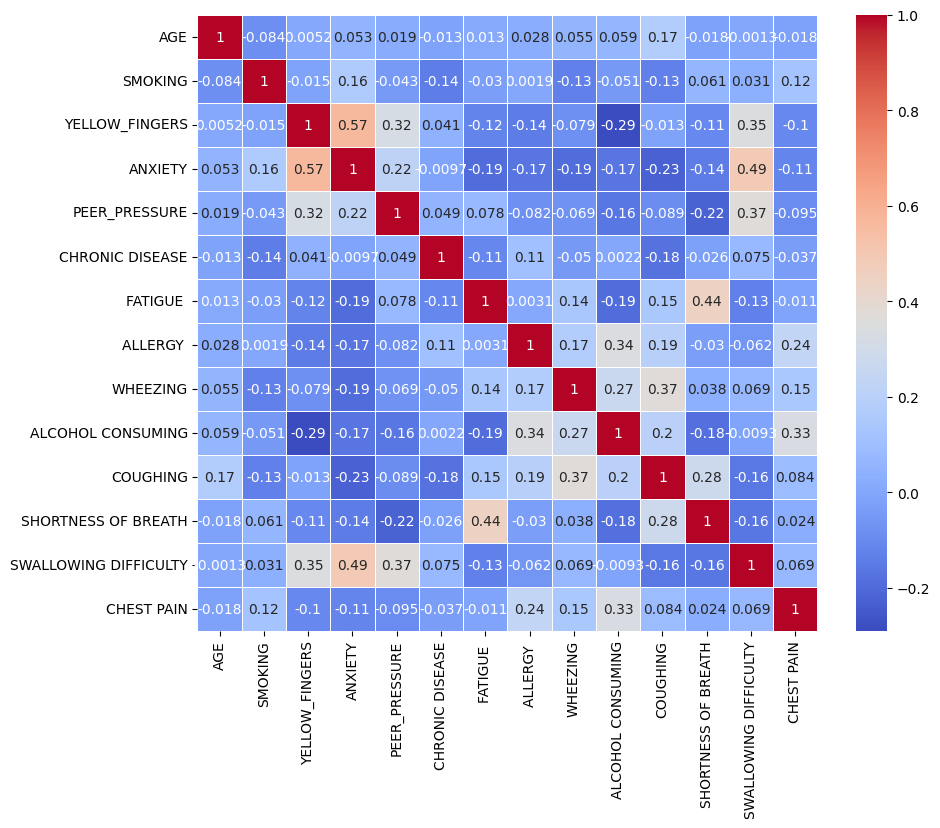

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# seleccionar solo las columnas numericas para la matriz de correlacion
df_numeric = df.select_dtypes(include=['int64', 'float64'])

#calcular la matriz
correlation_matrix = df_numeric.corr()

#crear un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

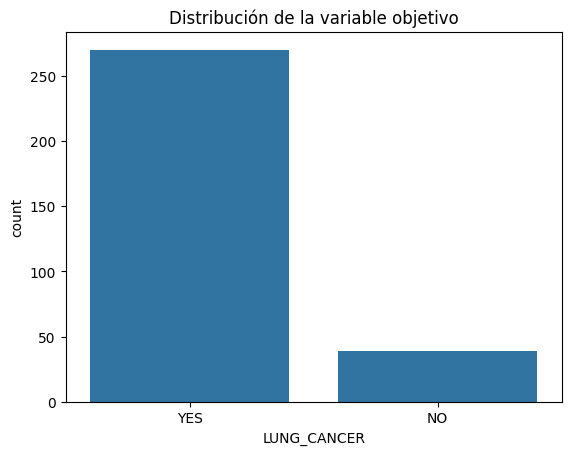

In [8]:
# conteo de pacientes con y sin cancer
sns.countplot(x="LUNG_CANCER", data=df)
plt.title("Distribución de la variable objetivo")
plt.show()

El propósito de este último gráfico fue para checar si nuestra variable objetivo (lung_cancer) esta desbalanceada. Ya que, para el siguiente paso, que es hacer la particion de los datos (train/test) es escencial saber si es necesario la partición estratificada.

Casi siempre con problemas de clasificación es casi obligatorio usar la estratificación a la hora de hacer la partición, y en este caso no es la excepción.

In [9]:
# sacar dichos datos del gráfico en porcentaje, para apreciar mejor el desbalanceo
print(df['LUNG_CANCER'].value_counts(normalize=True) * 100)

LUNG_CANCER
YES    87.378641
NO     12.621359
Name: proportion, dtype: float64


In [10]:
# 3º Realizar la partición en Train y Test
from sklearn.model_selection import train_test_split

# Separar las features (X) y nuestro target (y)
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# realizar la particion estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nDistribucion de LUNG_CANCER en train:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribucion de LUNG_CANCER in test:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (247, 15)
Testing set shape: (62, 15)

Distribucion de LUNG_CANCER en train:
LUNG_CANCER
YES    87.449393
NO     12.550607
Name: proportion, dtype: float64

Distribucion de LUNG_CANCER in test:
LUNG_CANCER
YES    87.096774
NO     12.903226
Name: proportion, dtype: float64


In [35]:
# hacer una copia de train
df_train = X_train.copy()
df_train['LUNG_CANCER'] = y_train
# 4º Realizar otra exploracion de los datos
df_train.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
26,F,61,2,2,2,1,1,2,2,1,2,1,2,2,2,YES
47,F,64,2,2,1,2,1,2,1,2,2,2,1,2,2,YES
198,F,73,2,2,2,1,2,1,2,1,2,1,1,1,1,YES
90,F,62,1,1,1,2,1,1,1,2,2,1,1,2,2,YES
303,M,51,1,2,1,1,2,2,2,2,2,2,2,1,2,YES


In [15]:
df_train.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.00000,247.000000,247.000000,247.000000,247.000000
mean,62.983806,1.550607,1.562753,1.465587,1.493927,1.485830,1.700405,1.587045,1.582996,1.57085,1.627530,1.647773,1.449393,1.566802
std,7.808151,0.498442,0.497054,0.499827,0.500978,0.500814,0.459011,0.493365,0.494065,0.49596,0.484444,0.478634,0.498442,0.496524
min,38.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
25%,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [17]:
df_train.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


<Axes: >

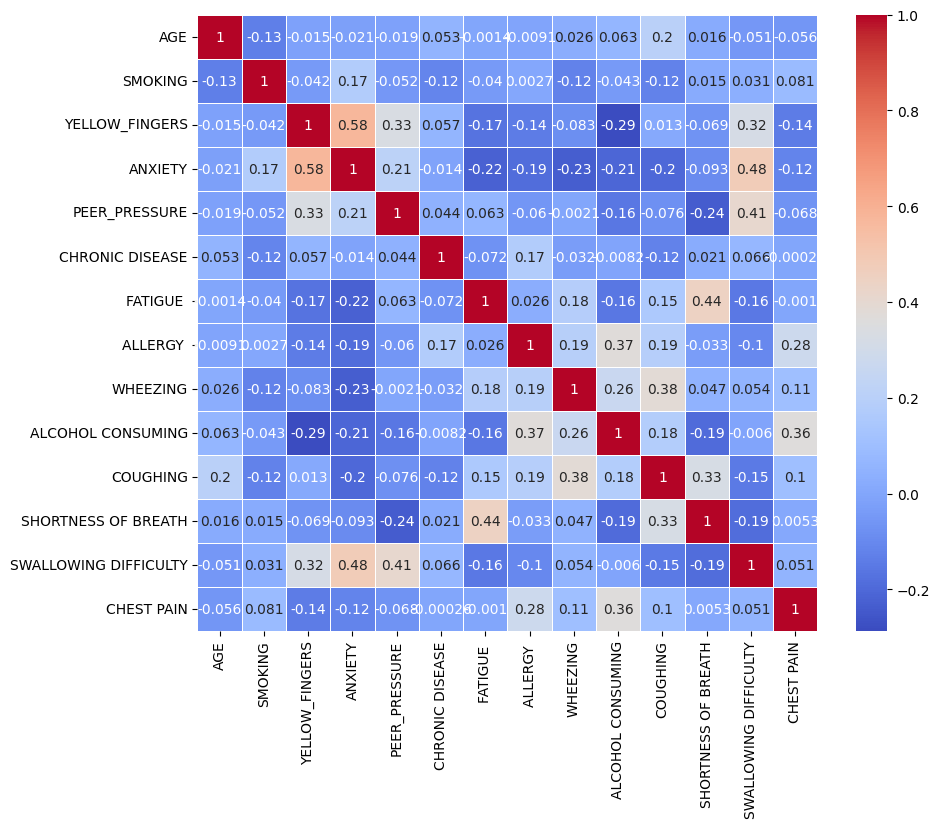

In [18]:
# 5º Obtener matriz de correlación  y gráficas de plotteo de características de conjunto de datos
# seleccionar solo las columnas numericas para la matriz de correlacion
df_numeric = df_train.select_dtypes(include=['int64', 'float64'])

#calcular la matriz
correlation_matrix = df_numeric.corr()

#crear un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

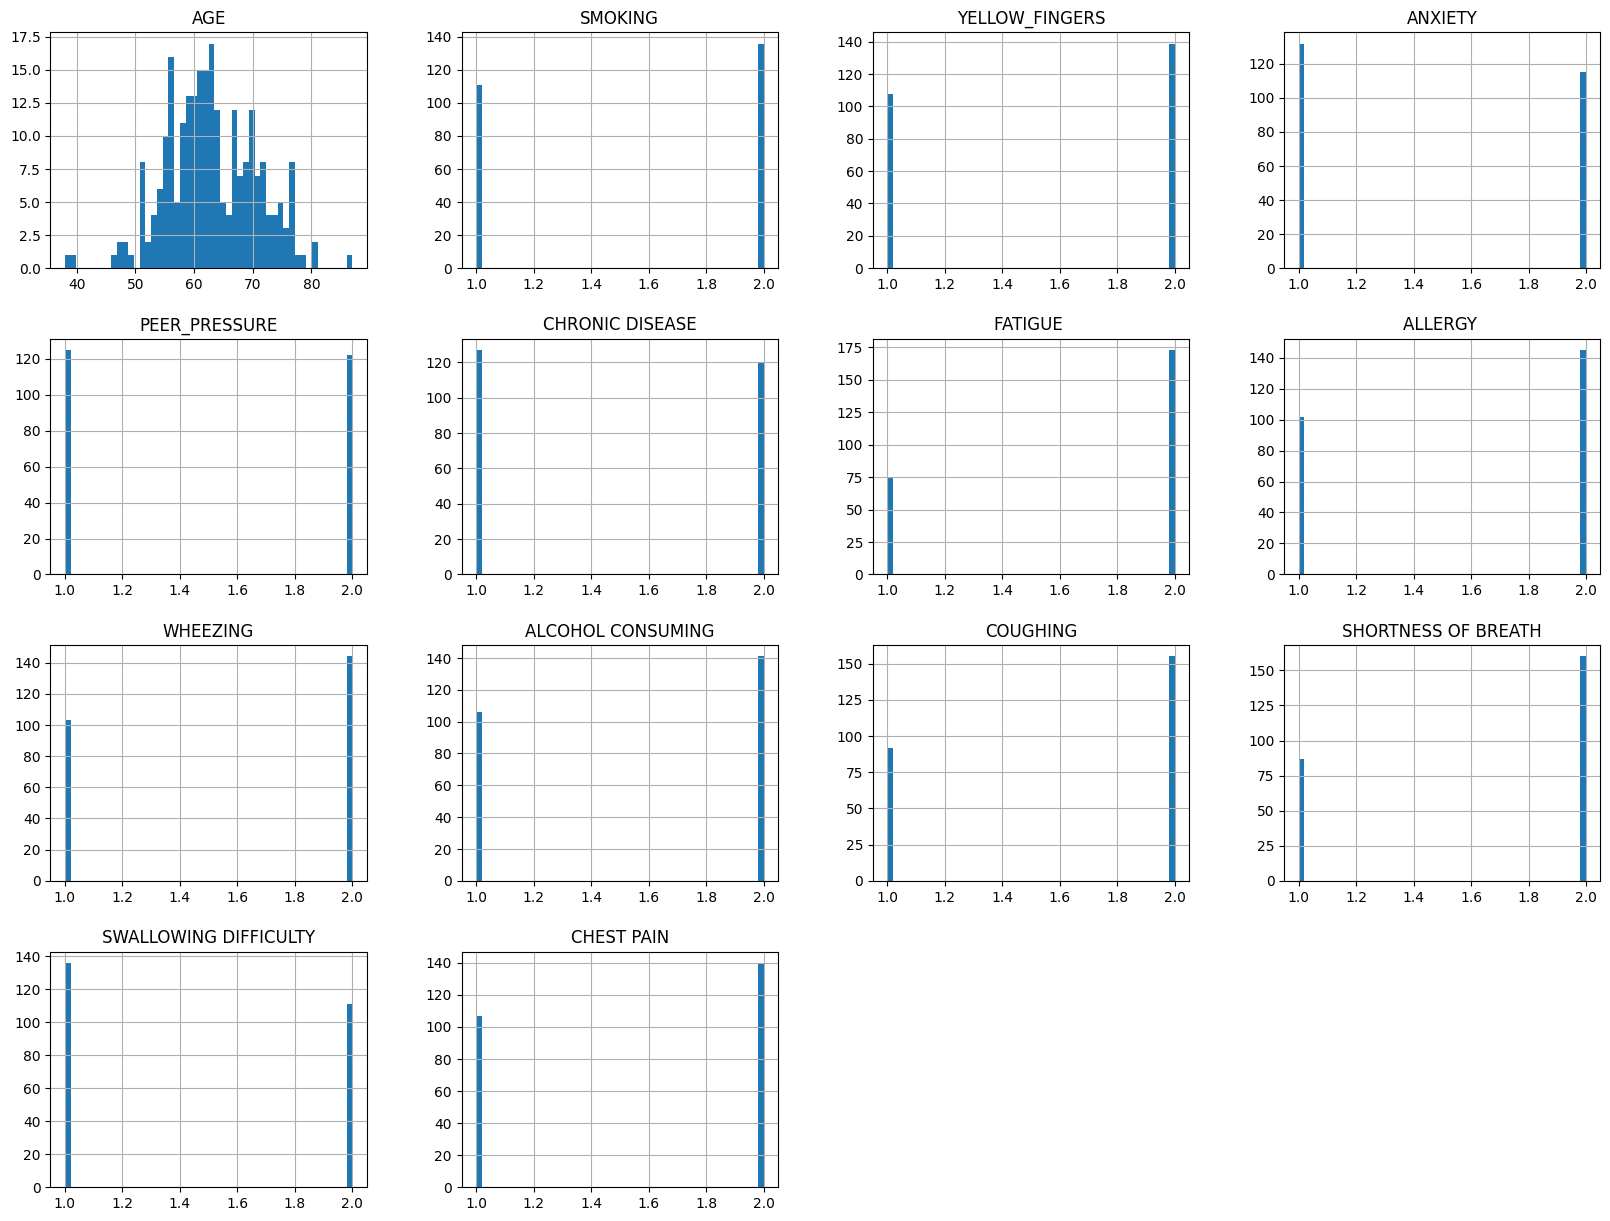

In [36]:
# obtener graficas
df_numeric = df_train.select_dtypes(include=['int64', 'float64'])
df_numeric.hist(bins=50, figsize=(20, 15))
plt.show()

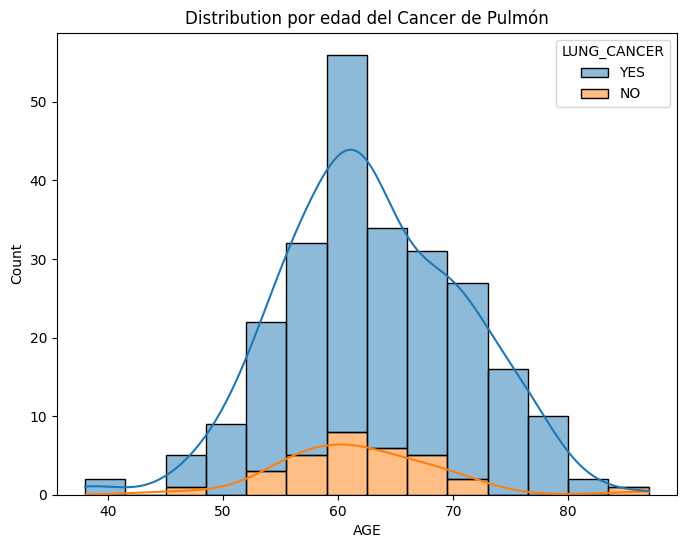

In [22]:
# Visualizar la distribucion por edad del cancer de Pulmón
plt.figure(figsize=(8, 6))
sns.histplot(data=df_train, x='AGE', hue='LUNG_CANCER', multiple='stack', kde=True)
plt.title('Distribution por edad del Cancer de Pulmón')
plt.show()

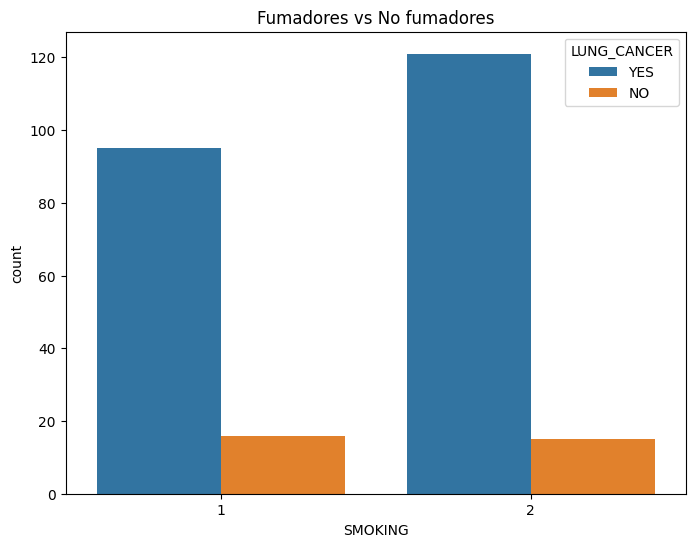

In [28]:
# Visualizar la cantidad de fumadores y no fumadores y su relación con el cancer
# 1 = No fumador, 2 = fumador
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='SMOKING', hue='LUNG_CANCER')
plt.title('Fumadores vs No fumadores')
plt.show()

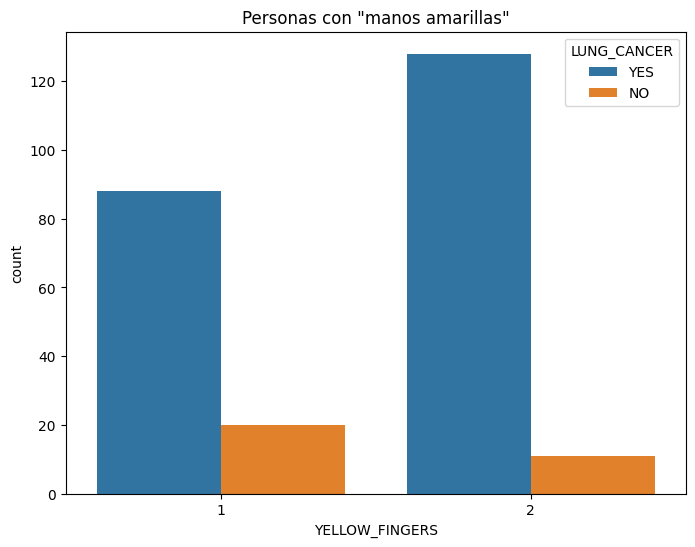

In [30]:
# Visualizar la cantidad de personas con las manos de color amarillas (yellow_fingers) y su relacion con el cancer
# 1 = No , 2 = Si
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='YELLOW_FINGERS', hue='LUNG_CANCER')
plt.title('Personas con "manos amarillas"')
plt.show()

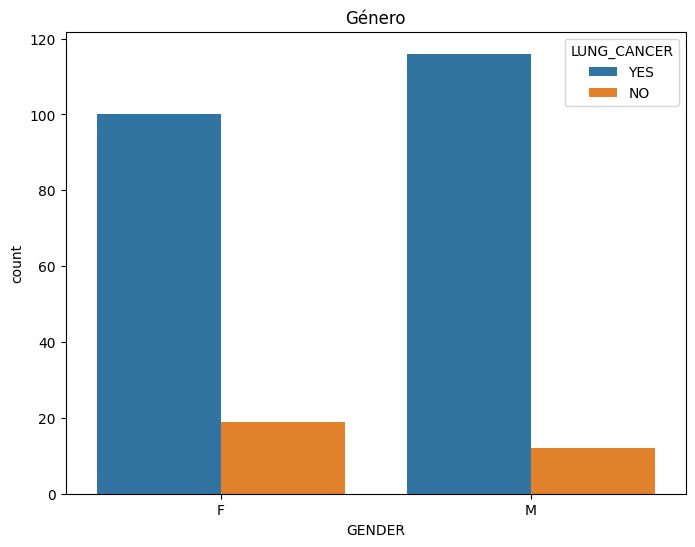

In [33]:
# Visualizar la cantidad de personas por genero
# Gender: M(male), F(female)
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='GENDER', hue='LUNG_CANCER')
plt.title('Género')
plt.show()

In [40]:
# 6º implementar la transformación de los datos por medio de un pipeline.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Identificar columnas numéricas y categóricas
# Excluyendo la variable objetivo 'Lung_cancer' porque ya está separada
numerical_features = ['AGE']
categorical_features = ['GENDER']

other_numerical_features = ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
                           'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
                           'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
                           'SWALLOWING DIFFICULTY', 'CHEST PAIN']

# Crear pipelines de preprocesamiento para características numéricas y categóricas
numerical_pipeline = Pipeline([

    ('scaler', MinMaxScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar los pasos de preprocesamiento utilizando ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features + other_numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Ajustar y transformar los datos de train
X_train_processed = preprocessor.fit_transform(X_train)

# Forma de los datos de train
print("Shape of processed training data:", X_train_processed.shape)

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN'],
      dtype='object')
Shape of processed training data: (247, 16)


El objetivo de este código es preparar los datos de entrenamiento (X_train) para ser utilizados por el modelo de Machine Learning. Los modelos a menudo requieren que los datos estén en un formato numérico y en una escala similar para funcionar correctamente y de manera eficiente.

1.   Importación de Librerias:
    
  * ColumnTransformer: Esta herramienta de scikit-learn te permite aplicar diferentes transformaciones a diferentes columnas de tu dataset simultáneamente. Es muy útil cuando tienes columnas de diferentes tipos (numéricas, categóricas) que requieren preprocesamiento distinto.
  * MinMaxScaler: Este es un escalador que transforma las características numéricas escalándolas a un rango dado, generalmente entre 0 y 1. Esto ayuda a que las características numéricas estén en una escala comparable, lo cual es importante para muchos algoritmos de Machine Learning (como SGDClassifier).
  * OneHotEncoder: Este codificador se utiliza para convertir variables categóricas nominales (como 'GENDER', que tiene categorías 'M' y 'F') en un formato numérico que los modelos puedan entender. Crea una nueva columna binaria por cada categoría única en la característica original.
  * Pipeline: La clase Pipeline te permite encadenar múltiples pasos de preprocesamiento y un estimador en un solo objeto. Esto simplifica tu código y asegura que los pasos de preprocesamiento se apliquen de manera consistente tanto a los datos de entrenamiento como a los de prueba.
2.   Identificar Columnas:
  * Se definen listas para separar los nombres de las columnas numéricas (numerical_features) y categóricas (categorical_features) que serán preprocesadas. La variable objetivo ('LUNG_CANCER') no se incluye aquí porque se separo previamente.
  * other_numerical_features incluye las columnas que, aunque representadas como 1 y 2, se tratan como numéricas para aplicarles el escalado.
  3. Crear Pipelines para Tipos de Datos:
  * numerical_pipeline: Se crea un Pipeline específico para las características numéricas. En este caso, solo incluye el paso de escalado con MinMaxScaler(). Si hubiera valores nulos en las columnas numéricas, aquí se añadiría un paso de imputación antes del escalado.
  * categorical_pipeline: Se crea un Pipeline para las características categóricas. Aquí solo se incluye el paso de OneHotEncoder(). handle_unknown='ignore' es útil para manejar posibles categorías nuevas en el conjunto de prueba que no se vieron en el entrenamiento, asignándoles ceros en todas las columnas codificadas.
  4. Combinar Pasos con ColumnTransformer:
* Se crea un objeto preprocessor usando ColumnTransformer.
* Se le pasan tuplas que especifican:
    * Un nombre para el transformador ('num', 'cat').
    * El pipeline a aplicar ( numerical_pipeline, categorical_pipeline).
    * La lista de columnas a las que se aplicará ese pipeline (numerical_features + other_numerical_features para el pipeline numérico, categorical_features para el pipeline categórico).
* ColumnTransformer se encargará de aplicar cada pipeline a las columnas correctas y luego concatenar los resultados.
5. Ajustar y Transformar los Datos de Entrenamiento:
  * preprocessor.fit_transform(X_train): Este es el paso donde el pipeline de preprocesamiento "aprende" de los datos de entrenamiento (fit) y luego aplica las transformaciones (transform).
    * fit: Calcula los parámetros necesarios para las transformaciones (por ejemplo, el mínimo y máximo para MinMaxScaler, las categorías únicas para OneHotEncoder) utilizando solo los datos de X_train.
    * transform: Aplica estas transformaciones a X_train utilizando los parámetros aprendidos en el paso fit.
  * El resultado es X_train_processed, que es un array NumPy con todos los datos de entrenamiento preprocesados y listos para ser utilizados por el modelo.

  6. Verificar la Forma de los Datos Procesados:
    * print("Shape of processed training data:", X_train_processed.shape): Imprime las dimensiones del array NumPy resultante. La cantidad de filas debe ser la misma que en X_train, y la cantidad de columnas será la original menos la columna categórica, más las nuevas columnas binarias creadas por OneHotEncoder para cada categoría única de 'GENDER'.


En resumen, este pipeline automatiza y organiza los pasos necesarios para transformar los datos brutos de entrenamiento en un formato adecuado para el entrenamiento del modelo de regresión logística, asegurando que el escalado y la codificación se apliquen correctamente a las columnas apropiadas.





In [41]:
# mostrar el dataframe despues de la transformacion
df_train_processed = pd.DataFrame(X_train_processed)
df_train_processed.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.469388,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0
1,0.530612,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2,0.714286,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.489796,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.265306,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0


In [46]:
# 7º Implementaciones
# a) modelo de clasificador SGD sin ajustar parametros con Cross-validation
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Dado que cross_val_score espera etiquetas numéricas para la clasificación,
# Necesitamos codificar la variable objetivo y_train
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Crear una instancia de SGDClassifier con parámetros predeterminados
# Configuración de pérdida='log_loss' para regresión logística
sgd_clf = SGDClassifier(loss='log_loss', random_state=42)

# Realizar una validación cruzada de 10 particiones
# Utilizar los datos de entrenamiento procesados ​​X_train_processed y codificados y_train_encoded
cv_scores = cross_val_score(sgd_clf, X_train_processed, y_train_encoded, cv=10)

# c) Realiza la evaluación del modelo  sin ajustar
# Imprimir las puntuaciones de cross validation
print("Cross-validation scores (10 particiones):", cv_scores)
print("Precisión media de cross-validation:", np.mean(cv_scores))

Cross-validation scores (10 particiones): [1.         0.92       0.76       0.88       0.96       0.92
 0.92       0.875      0.95833333 0.91666667]
Precisión media de cross-validation: 0.9109999999999999


### Cross-validation scores (10 particiones): [1., 0.92, 0.76, 0.88, 0.96, 0.92, 0.92, 0.875, 0.95833333, 0.91666667]
    
Estas son las puntuaciones de precisión para cada uno de los 10 pliegues (o subconjuntos) de los datos de entrenamiento durante la validación cruzada. Cada puntuación representa el rendimiento del modelo en ese pliegue en particular al entrenarse con los 9 pliegues restantes.

Podemos observar que las puntuaciones varían significativamente entre los pliegues, desde un máximo de 1,0 (100 % de precisión) hasta un mínimo de 0,76 (76 % de precisión). Esta variación sugiere que el rendimiento del modelo podría ser sensible al subconjunto específico de datos con el que se entrena y evalúa. Algunos pliegues se predijeron correctamente, mientras que otros presentaron un número considerable de errores.
    
### Mean cross-validation accuracy: 0.9109999999999999 (approximately 91.1%)
    
  Este es el promedio de las puntuaciones de precisión en los 10 pliegues. Proporciona una estimación más robusta del rendimiento del modelo con datos no vistos, en comparación con una única división de entrenamiento y prueba. Una precisión media de alrededor del 91,1 % indica que, en promedio, el clasificador SGD predice correctamente si alguien tiene cáncer de pulmón o no en aproximadamente el 91,1 % de las ocasiones con los datos de entrenamiento, al evaluarse mediante validación cruzada.

### Interpretación general:

La precisión media del 91,1 % parece bastante buena. Sin embargo, la notable varianza en las puntuaciones de cada pliegue (del 76 % al 100 %) sugiere que el modelo podría no ser perfectamente consistente en los diferentes subconjuntos de datos.

Dado el desequilibrio de clases observado anteriormente (87,4 % de "SÍ" y 12,6 % de "NO" en el conjunto de entrenamiento), la precisión por sí sola podría no ser la mejor métrica para evaluar el modelo, especialmente si el objetivo es identificar correctamente la clase minoritaria (cáncer de pulmón "NO"). La alta precisión podría deberse en parte a que el modelo predice "SÍ" la mayor parte del tiempo.

Después de realizar este modelo de clasificador SGD sin ajustar parametros usando cross-validation, se implemento otro clasificador SGD, pero ahora, buscando los mejores parametros usando Grid Search o Random Search, y comparar el "Accuracy" para obtener el mejor modelo.

Dado que el SGDClassifier tiene varios hiperparámetros que se pueden ajustar y no sabemos de antemano cuáles son los más importantes, se opto por usar Random Search sobre Grid Search. Ya que permitire explorar un espacio de búsqueda más amplio de manera más eficiente y potencialmente encontrar buenos valores para los hiperparámetros más influyentes sin la necesidad de probar todas las combinaciones posibles.

### Parámetros Ajustables para SGDClassifier (con loss='log_loss'):

Para el SGDClassifier cuando se usa como regresión logística (loss='log_loss'), algunos de los hiperparámetros más importantes que puedes ajustar incluyen:


*   loss: Ya esta configurado como 'log_loss' para regresión logística. Otros valores posibles son para diferentes tipos de modelos lineales.
*   penalty: El tipo de regularización a aplicar. Puede ser 'l2' (regularización Ridge), 'l1' (regularización Lasso) o 'elasticnet' (una combinación de L1 y L2). La regularización ayuda a prevenir el overfitting
* alpha: Constante que multiplica el término de regularización. Un valor más alto impone una regularización más fuerte. Es un parámetro crucial para ajustar con penalty.
* l1_ratio: El ratio de regularización L1 cuando penalty='elasticnet'. Un valor de 0 corresponde a L2 puro y un valor de 1 a L1 puro. Solo es relevante si penalty='elasticnet'
* max_iter: El número máximo de pasadas sobre los datos de entrenamiento (épocas). Debería ser lo suficientemente grande para que el modelo converja.
* tol: El criterio de parada. El entrenamiento se detendrá cuando la pérdida no mejore en al menos tol durante n_iter_no_change épocas consecutivas.
* learning_rate: La estrategia para la tasa de aprendizaje. Puede ser 'constant', 'optimal', 'invscaling' o 'adaptive'
* early_stopping: Si se debe usar la parada temprana para terminar el entrenamiento cuando la puntuación de validación no mejora.
* validation_fraction: La proporción de datos de entrenamiento que se reservarán para la validación temprana. Solo se usa si early_stopping es True.
* n_iter_no_change: Número de épocas sin mejora para activar la parada temprana. Solo se usa si early_stopping es True.



In [47]:
# b) Implementar y optimizar modelo SGD con Random Search

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import numpy as np
from scipy.stats import uniform, reciprocal

# Dado que cross_val_score y RandomizedSearchCV requieren etiquetas numéricas para la clasificación,
# necesitamos codificar la variable objetivo y_train. Ya lo hicimos en una celda anterior,
# pero es recomendable asegurarse de que esté hecho antes de usarlo en la optimización.
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)


# Crear una instancia de SGDClassifier con pérdida='log_loss'
sgd_clf = SGDClassifier(loss='log_loss', random_state=42)

# Definir la distribución de parámetros para la búsqueda aleatoria
# Se exploro un rango de valores para hiperparámetros clave
param_distributions = {
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': reciprocal(0.0001, 1.0), # El alpha puede variar en un amplio rango
    'l1_ratio': uniform(0, 1),       # Solo es relevante si se usa elasticnet
    'max_iter': [1000, 2000, 3000],  # Numero de épocas
    'tol': [1e-3, 1e-4, 1e-5],       # Tolerancia para el criterio de parada
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': reciprocal(0.001, 0.1),  # Tasa de aprendizaje inicial
    'early_stopping': [True, False],
    'validation_fraction': [0.1, 0.2, 0.3], # Solo se utiliza si early_stopping es True
    'n_iter_no_change': [5, 10, 20] # Solo se utiliza si early_stopping es True
}

# Crear un objeto RandomizedSearchCV
# n_iter: número de parámetros muestreados.
# cv: número de veces que se realiza la validación cruzada.
random_search = RandomizedSearchCV(
    sgd_clf,
    param_distributions=param_distributions,
    n_iter=100,  # Se puede aumentar este número para una búsqueda más exhaustiva
    cv=10,       # cross-validation de 10 particiones
    scoring='accuracy',
    random_state=42,
    n_jobs=-1    # Utiliza todos los núcleos de CPU disponibles
)

# Ajustar RandomizedSearchCV a los datos de entrenamiento procesados
random_search.fit(X_train_processed, y_train_encoded)

# d) Obtener los mejores parámetros y la mejor puntuación encontrada
print("Best parameters found:", random_search.best_params_)
print("Best cross-validation accuracy:", random_search.best_score_)

# El mejor modelo está disponible como random_search.best_estimator_
best_sgd_model = random_search.best_estimator_

Best parameters found: {'alpha': np.float64(0.0003613894271216529), 'early_stopping': False, 'eta0': np.float64(0.08861577452533075), 'l1_ratio': np.float64(0.23277134043030423), 'learning_rate': 'optimal', 'max_iter': 3000, 'n_iter_no_change': 10, 'penalty': 'elasticnet', 'tol': 1e-05, 'validation_fraction': 0.1}
Best cross-validation accuracy: 0.9393333333333332


### Interpretacion de "Best parameters found"

*   alpha: Un valor pequeño (0.00036...) sugiere que una regularización relativamente débil (el término de penalización no tiene un peso muy alto) fue óptima para este conjunto de datos y modelo.
*   early_stopping: False indica que detener el entrenamiento antes de max_iter basándose en una fracción de validación no mejoró el rendimiento en este caso. El modelo entrenó durante el número máximo de iteraciones permitido (max_iter).
* eta0: La tasa de aprendizaje inicial (0.0886...) es el valor de partida para ajustar los pesos del modelo durante el entrenamiento
* l1_ratio: Este valor (0.2327...) es relevante porque el penalty óptimo fue 'elasticnet'. Sugiere que una combinación de regularización L1 y L2 (con un mayor peso en L2 ya que el valor está más cerca de 0 que de 1) fue lo mejor.
* learning_rate: 'optimal' es una estrategia de tasa de aprendizaje que se calcula de forma óptima al principio y luego disminuye gradualmente. Esto resultó ser la estrategia más efectiva en la búsqueda.
* max_iter: El modelo entrenó durante el máximo de 3000 iteraciones.
* n_iter_no_change: Aunque early_stopping fue False, este parámetro define el número de épocas sin mejora que hubieran activado la parada temprana si estuviera habilitada. Su valor es 10.
* penalty: 'elasticnet' significa que la mejor regularización encontrada es una combinación de L1 y L2. Esto puede ayudar a manejar la multicolinealidad y a seleccionar características.
* tol: Un valor de 1e-05 es un criterio de parada estricto, lo que significa que el entrenamiento continuó hasta que la mejora en la pérdida fue muy pequeña.
* validation_fraction: Este parámetro (0.1) es la proporción de datos usados para validación temprana si early_stopping fuera True. No tuvo efecto en este caso ya que early_stopping fue False.

### Best cross-validation accuracy: 0.9393333333333332 (aproximadamente 93.9%)

Esta es la precisión media más alta que Randomized Search encontró entre todas las combinaciones de hiperparámetros que probó, evaluada usando validación cruzada de 10 particiones.

### Comparación con el modelo sin ajustar:

* El modelo SGD sin ajustar obtuvo una precisión media de validación cruzada de aproximadamente 91.1%.
* El modelo SGD con hiperparámetros ajustados mediante Random Search obtuvo una precisión media de validación cruzada de aproximadamente 93.9%.

### Interpretación General:

La búsqueda aleatoria de hiperparámetros logró mejorar la precisión media de validación cruzada en comparación con el modelo con parámetros predeterminados (de 91.1% a 93.9%). Esto sugiere que la optimización de los hiperparámetros fue efectiva para encontrar una configuración que permite al modelo generalizar mejor en los datos de entrenamiento (evaluado a través de la validación cruzada).
El hecho de que 'elasticnet' con un bajo alpha y un l1_ratio que favorece L2 sea el mejor penalty y que 'optimal' sea el mejor learning_rate son hallazgos importantes de la búsqueda.









In [50]:
# 8º Realizar la evaluación del mejor modelo usando el conjunto de "Test"

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Transformar los datos de prueba usando el preprocesador ajustado en los datos de entrenamiento
X_test_processed = preprocessor.transform(X_test)

# El mejor modelo está disponible como random_search.best_estimator_
# Se nececita hacer predicciones sobre los datos de prueba procesados
y_pred = best_sgd_model.predict(X_test_processed)

# Las etiquetas originales de y_test son strings ('YES', 'NO').
# Para calcular métricas, necesitamos asegurarnos de que tanto y_test como y_pred estén en el mismo formato
# Codificaremos y_test usando el mismo LabelEncoder ajustado en y_train
label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)

# Si el best_sgd_model produce predicciones codificadas, se usan directamente.
# Si produce predicciones en string, puede que se necesite codificar y_pred también,
# pero típicamente los modelos de sklearn producen la salida basándose en cómo fueron ajustados/entrenados.
# Si y_pred fuera strings, se necesitarías:
# y_pred_encoded = label_encoder.transform(y_pred)
# y luego usar y_pred_encoded en las métricas.

# Evaluar el modelo en el conjunto de prueba
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred) # Por defecto, usa la etiqueta positiva (clase 1)
recall = recall_score(y_test_encoded, y_pred)     # Por defecto, usa la etiqueta positiva (clase 1)
f1 = f1_score(y_test_encoded, y_pred)           # Por defecto, usa la etiqueta positiva (clase 1)
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

# 9º Imprimir las métricas de evaluación
print("Evaluación del conjunto de test:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Evaluación del conjunto de test:
Accuracy: 0.9355
Precision: 0.9808
Recall: 0.9444
F1-score: 0.9623


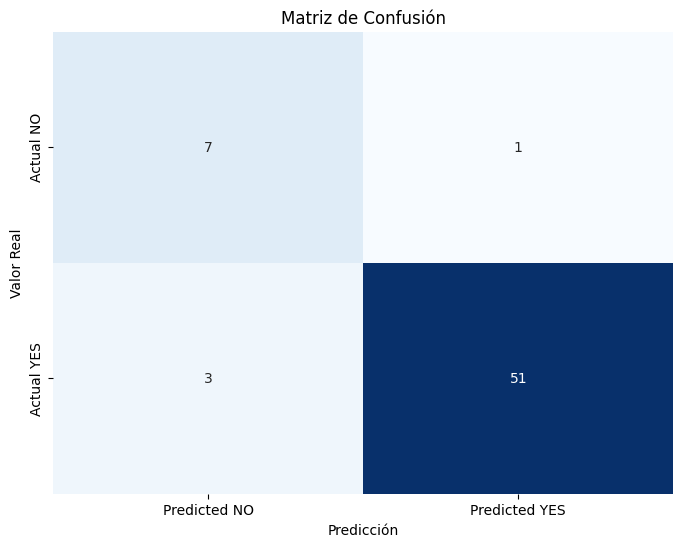

In [49]:
# 10º obtener la matriz de confusión para identificar la cantidad de instancias que fueron correctamente clasificadas y las que no
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Visualize la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted NO', 'Predicted YES'],
            yticklabels=['Actual NO', 'Actual YES'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

## Conclusión

En esta práctica, hemos aplicado un flujo completo de Data Science para abordar el problema de predicción de cáncer de pulmón utilizando un clasificador de Regresión Logística (implementado a través de `SGDClassifier` con `loss='log_loss'`) en el dataset de Kaggle.

**Interpretación de los Resultados y Contraste con Regresión Lineal:**

Hemos observado que la Regresión Logística, a diferencia de la Regresión Lineal que predice un valor continuo, está diseñada para problemas de clasificación, prediciendo la probabilidad de que una instancia pertenezca a una clase particular (en este caso, tener o no tener cáncer de pulmón). La función de pérdida (`log_loss` o entropía cruzada) utilizada en la Regresión Logística penaliza las predicciones incorrectas de probabilidad, lo que la hace adecuada para este tipo de tarea binaria.

El modelo inicial de `SGDClassifier` sin ajustar parámetros mostró una precisión media de validación cruzada de aproximadamente 91.1%. Aunque este número parece alto, la variabilidad en las puntuaciones de los diferentes pliegues de validación cruzada (desde 76% hasta 100%) sugirió que el modelo podría ser inestable o sensible a los datos específicos de cada pliegue.

Al aplicar Random Search para optimizar los hiperparámetros del `SGDClassifier`, logramos mejorar la precisión media de validación cruzada a aproximadamente 93.9%. Los mejores parámetros encontrados, como el uso de regularización `elasticnet` con un `alpha` bajo y una tasa de aprendizaje `optimal`, indican que la regularización fue beneficiosa para el modelo y que la estrategia de aprendizaje influyó positivamente en su convergencia y rendimiento.

La evaluación final en el conjunto de prueba, que representa datos completamente no vistos, arrojó las siguientes métricas:

*   **Accuracy (Precisión general):** 0.9355
*   **Precision (Precisión de la clase positiva - Cáncer YES):** 0.9808
*   **Recall (Sensibilidad de la clase positiva - Cáncer YES):** 0.9444
*   **F1-score (Medida balanceada):** 0.9623

## Referencias

**Librerías usadas:**

*   **pandas:** Utilizada para la manipulación y análisis de datos.
*   **scikit-learn:** Librería fundamental para Machine Learning, utilizada para la división de datos, preprocesamiento (escalado, codificación) y modelos de regresión.
*   **matplotlib y seaborn:** Utilizadas para la visualización de datos.
*   **numpy:** Utilizada para operaciones numéricas, especialmente en el cálculo de RMSE.
* **scipy.stats:** Utilizada generar las distribuciones uniform y reciprocal, que son necesarias para especificar los rangos de valores que RandomizedSearchCV debe muestrear al buscar los mejores hiperparámetros para tu modelo.

**Fuente de la base de Datos:**

*   **Kaggle Dataset:** [Lung cancer](https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer)